# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Dianyra Liliana Diaz Sandoval, Cristhian Alejandro Diaz Fernandez, Juan Diego Baca Laserna, Frank Omar Desposorio Pulido, Felix Mitchel Ruiz Cabello |
| **Título del Proyecto** | Entrenamiento de un modelo para deteccion de fraude |
| **Fecha de Entrega** | 25 de agosto del 2026 |
| **Profesor** | Carlos Mariño del Rosario |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---

*[Escriba su resumen ejecutivo aquí]*





---

## 2. Configuración del Entorno

### 2.1 Verificación de GPU (Recomendado para Deep Learning)

In [1]:
# Verificar si hay GPU disponible
import torch

# Verificar disponibilidad de GPU
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    print("⚠️ GPU no disponible. Usando CPU.")
    print("   Recomendación: En Colab, vaya a Runtime > Change runtime type > GPU")
    device = torch.device('cpu')

print(f"\nDispositivo seleccionado: {device}")

✅ GPU disponible: Tesla T4
   Memoria GPU: 15.64 GB

Dispositivo seleccionado: cuda


### 2.2 Instalación de Librerías Adicionales (si es necesario)

In [2]:
# Descomente e instale las librerías adicionales que necesite
# !pip install transformers
# !pip install pytorch-lightning
# !pip install optuna
# !pip install shap
# !pip install lime

### 2.3 Importación de Librerías

In [3]:
# =====================================================
# LIBRERÍAS FUNDAMENTALES
# =====================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Deep Learning - TensorFlow/Keras (alternativa)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Utilidades
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("✅ Todas las librerías importadas correctamente")
print(f"   PyTorch version: {torch.__version__}")
print(f"   TensorFlow version: {tf.__version__}")

✅ Todas las librerías importadas correctamente
   PyTorch version: 2.11.0+cu128
   TensorFlow version: 2.20.0


### 2.4 Conexión con Google Drive (para cargar datos)

In [5]:
# Montar Google Drive para acceder a los datos
from google.colab import drive
drive.mount('/content/drive')

# Definir la ruta base de su proyecto
# Modifique esta ruta según la ubicación de sus datos
BASE_PATH = '/content/drive/MyDrive/Capstone_Project/'
DATA_PATH = BASE_PATH + 'data/Data - CURSO BIG DATA - GRUPO 3.csv'

print(f"✅ Google Drive montado")
print(f"   Ruta base del proyecto: {BASE_PATH}")

Mounted at /content/drive
✅ Google Drive montado
   Ruta base del proyecto: /content/drive/MyDrive/Capstone_Project/


---
## 3. Definición del Problema de Negocio

### 3.1 Contexto del Negocio

**Instrucciones:** Describa el contexto empresarial, incluyendo:
- Industria/Sector: Financiero y Tecnología Bancaria / Servicios de Pago Digital (Fintech)
- Empresa o caso de estudio: Entidad de servicios de pago móvil y transferencias electrónicas digitales
- Situación actual:

---

La empresa opera una plataforma digital de procesamiento de transacciones financieras en tiempo real que maneja millones de operaciones mensuales (TRANSFER, CASH-OUT, PAYMENT, CASH-IN, DEBIT). El monitoreo actual de seguridad se basa en un sistema tradicional de reglas de negocio rígidas



---

### 3.2 Problema a Resolver

**Instrucciones:** Defina claramente:
- ¿Cuál es el problema específico?
- ¿Por qué es importante resolverlo?
- ¿Cuál es el impacto actual del problema?

---

Las reglas de negocio estáticas actuales son ineficaces para detectar patrones de fraude complejos y fraccionados. Específicamente, los ciberdelincuentes están ejecutando patrones de vulneración donde toman el control de cuentas legítimas, vacían los fondos mediante transferencias por montos menores al umbral de control (evadiendo la regla de los 200,000) y proceden al retiro inmediato en efectivo (CASH-OUT).

Las pérdidas económicas derivadas del fraude financiero no detectado a tiempo generan un alto costo operativo directos para la institución, reducen la confianza de los usuarios en la plataforma y conllevan sanciones regulatorias por falta de controles de seguridad transaccionales adecuados. Provocando los siguientes impactos:

- Económico: Pérdidas financieras directas al tener que asumir el rembolso de fondos robados a los clientes.
- Operativo: Pérdida de eficiencia al requerir revisiones manuales de transacciones e incapacidad para responder a la velocidad de procesamiento requerida en un entorno de Big Data.  
- Reputacional: Incoformidad y migración de clientes hacia la competencia por falta de seguridad percibida.



---

### 3.3 Objetivos del Proyecto

**Instrucciones:** Liste los objetivos SMART (Específicos, Medibles, Alcanzables, Relevantes, Temporales)

---

**Objetivo General:**
Desarrollar y desplegar un pipeline escalable de Deep Learning para la detección y clasificación automatizada de transacciones financieras fraudulentas en tiempo real, procesando un volumen masivo de datos para reducir el fraude no detectado por las reglas tradicionales de negocio.

**Objetivos Específicos:**
1. Construir un pipeline automatizado de ingesta y preprocesamiento
2. Diseñar y entrenar un modelo predictivo de Deep Learning (MLP/Red Neuronal Densa
3. Evaluar el rendimiento del modelo en producción

---

### 3.4 Tipo de Problema de Machine Learning

**Instrucciones:** Identifique el tipo de problema:
- [X] Clasificación binaria
- [ ] Clasificación multiclase
- [ ] Regresión
- [ ] Clustering
- [ ] Series temporales
- [ ] Procesamiento de Lenguaje Natural (NLP)
- [ ] Visión por Computadora
- [ ] Otro: _________

**Justificación:**
Se trata de un problema de clasificación binaria debido a que la variable objetivo (isFraud) adopta únicamente dos estados mutuamente excluyentes: 1 (transacción fraudulenta) y 0 (transacción legítima). El modelo debe aprender los patrones sutiles en los saldos iniciales,finales, montos y tipos de operación para predecir a cuál de las dos categorías pertenece cada transacción procesada por el sistema.

---

---
## 4. Carga y Exploración de Datos

### 4.1 Carga de Datos

In [8]:
# =====================================================
# CARGA DE DATOS
# =====================================================

#Opción 1: Cargar desde Google Drive
df = pd.read_csv(DATA_PATH)

# Opción 2: Cargar desde URL
# df = pd.read_csv('https://url-de-sus-datos.com/datos.csv')

# Opción 3: Cargar desde archivo local (subido a Colab)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('nombre_archivo.csv')

# Opción 4: Dataset de ejemplo (para testing)
# from sklearn.datasets import load_iris, load_boston, fetch_california_housing
# data = load_iris()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

# =====================================================
# COMPLETE AQUÍ: Cargue su dataset
# =====================================================

# df = pd.read_csv('...')  # Descomente y complete

print(f"✅ Dataset cargado exitosamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
   Dimensiones: 6,362,620 filas × 11 columnas


### 4.2 Descripción del Dataset

**Instrucciones:** Describa su dataset:
- Fuente de los datos

El dataset utilizado corresponde a Financial Payment Services Fraud Data, obtenido de Kaggle. Los datos se basan en PaySim, un simulador de transacciones financieras móviles desarrollado a partir de una muestra de transacciones reales de un servicio de dinero móvil. El conjunto contiene información sobre operaciones financieras, saldos de las cuentas de origen y destino, tipos de transacción e indicadores de fraude.

- Período de tiempo que cubren

Los datos representan una simulación de 30 días de operaciones financieras. La variable step representa unidades de tiempo de una hora, alcanzando un total de 744 pasos temporales.

- Variable Objetivo

La variable objetivo es isFraud, de tipo binario, donde 0 representa una transacción no fraudulenta y 1 una transacción fraudulenta.

- Descripción de cada variable

---

| Variable | Tipo | Descripción |
|----------|------|-------------|
| step| numérica| Unidad temporal de la simulación. Cada paso representa una hora. |
| Type | categórica | Tipo de transacción: CASH-IN, CASH-OUT, DEBIT, PAYMENT o TRANSFER. |
| amount| numérica | Monto de la transacción en moneda local. |
| nameOrig| categórica | Identificador del cliente que origina la transacción. |
| oldbalanceOrg| Numérica| Saldo de la cuenta de origen antes de la transacción. |
| newbalanceOrig| Numérica| Saldo de la cuenta de origen después de la transacción.|
| nameDest| Categórica| Identificador del destinatario de la transacción.|
| oldbalanceDest| Numérica| Saldo de la cuenta de destino antes de la transacción.|
| newbalanceDest| Numérica| Saldo de la cuenta de destino después de la transacción.|
| isFraud|Binaria / objetivo| Indica si la transacción fue fraudulenta: 1 = fraude y 0 = no fraude.|
| iisFlaggedFraud|Binaria | Indica si la operación fue marcada por la regla del sistema como un intento ilegal.|
---

### 4.3 Exploración Inicial de Datos (EDA)

In [9]:
# =====================================================
# INFORMACIÓN GENERAL DEL DATASET
# =====================================================

print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Primeras filas
print("\n📊 Primeras 5 filas:")
display(df.head())

# Información del dataset
print("\n📋 Información del Dataset:")
print(df.info())

# Estadísticas descriptivas
print("\n📈 Estadísticas Descriptivas:")
display(df.describe())

INFORMACIÓN GENERAL DEL DATASET

📊 Primeras 5 filas:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0



📋 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

📈 Estadísticas Descriptivas:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [10]:
# =====================================================
# ANÁLISIS DE VALORES FALTANTES
# =====================================================

print("=" * 60)
print("ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)

# Calcular valores faltantes
missing_data = pd.DataFrame({
    'Total Faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Total Faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

if len(missing_data) > 0:
    print("\n⚠️ Variables con valores faltantes:")
    display(missing_data)

    # Visualización de valores faltantes
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y='Porcentaje (%)', data=missing_data)
    plt.title('Porcentaje de Valores Faltantes por Variable')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Porcentaje (%)')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No hay valores faltantes en el dataset")

ANÁLISIS DE VALORES FALTANTES

✅ No hay valores faltantes en el dataset


ANÁLISIS DE LA VARIABLE OBJETIVO: isFraud

📊 Distribución de clases:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


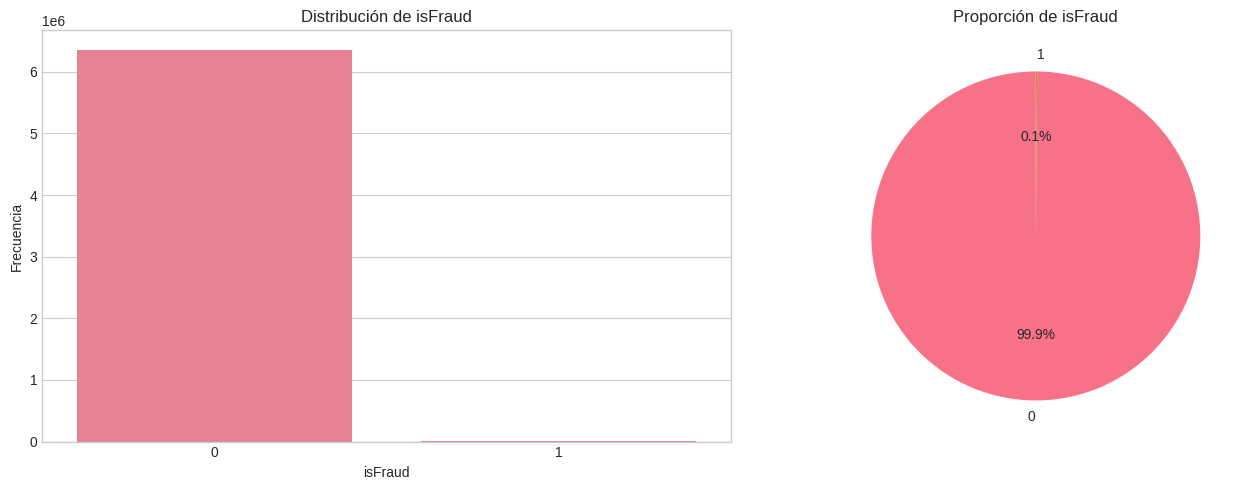


⚠️ ADVERTENCIA: Dataset desbalanceado (ratio 773.70:1)
   Considere técnicas de balanceo: SMOTE, undersampling, class weights


In [11]:
# =====================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# =====================================================

# COMPLETE: Especifique el nombre de su variable objetivo
TARGET_COLUMN = 'isFraud'  # Cambie 'target' por el nombre de su variable objetivo

print("=" * 60)
print(f"ANÁLISIS DE LA VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("=" * 60)

# Para clasificación
if df[TARGET_COLUMN].dtype == 'object' or df[TARGET_COLUMN].nunique() < 20:
    print("\n📊 Distribución de clases:")
    class_dist = df[TARGET_COLUMN].value_counts()
    print(class_dist)

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    sns.countplot(data=df, x=TARGET_COLUMN, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
    axes[0].set_xlabel(TARGET_COLUMN)
    axes[0].set_ylabel('Frecuencia')

    # Gráfico de pastel
    axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

    # Verificar desbalance
    imbalance_ratio = class_dist.max() / class_dist.min()
    if imbalance_ratio > 3:
        print(f"\n⚠️ ADVERTENCIA: Dataset desbalanceado (ratio {imbalance_ratio:.2f}:1)")
        print("   Considere técnicas de balanceo: SMOTE, undersampling, class weights")
else:
    # Para regresión
    print("\n📊 Estadísticas de la variable objetivo:")
    print(df[TARGET_COLUMN].describe())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    sns.histplot(df[TARGET_COLUMN], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribución de {TARGET_COLUMN}')

    # Box plot
    sns.boxplot(y=df[TARGET_COLUMN], ax=axes[1])
    axes[1].set_title(f'Box Plot de {TARGET_COLUMN}')

    plt.tight_layout()
    plt.show()

MATRIZ DE CORRELACIONES


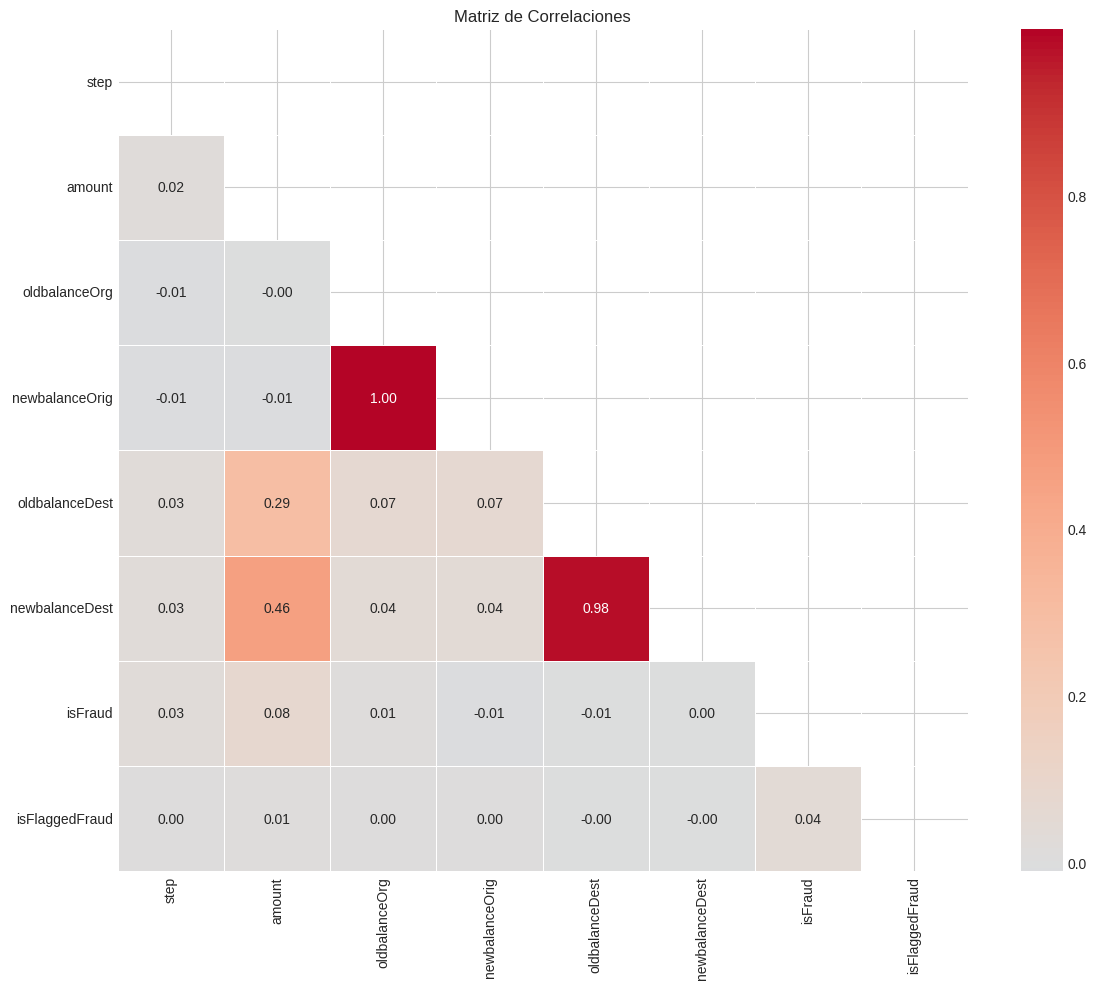


📊 Correlaciones con isFraud:
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [12]:
# =====================================================
# ANÁLISIS DE CORRELACIONES
# =====================================================

print("=" * 60)
print("MATRIZ DE CORRELACIONES")
print("=" * 60)

# Seleccionar solo columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 1:
    # Calcular correlaciones
    correlation_matrix = df[numeric_cols].corr()

    # Visualización
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                center=0, fmt='.2f', linewidths=0.5)
    plt.title('Matriz de Correlaciones')
    plt.tight_layout()
    plt.show()

    # Correlaciones con la variable objetivo
    if TARGET_COLUMN in numeric_cols:
        print(f"\n📊 Correlaciones con {TARGET_COLUMN}:")
        target_corr = correlation_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
        print(target_corr)
else:
    print("⚠️ No hay suficientes columnas numéricas para análisis de correlación")

VISUALIZACIONES ADICIONALES


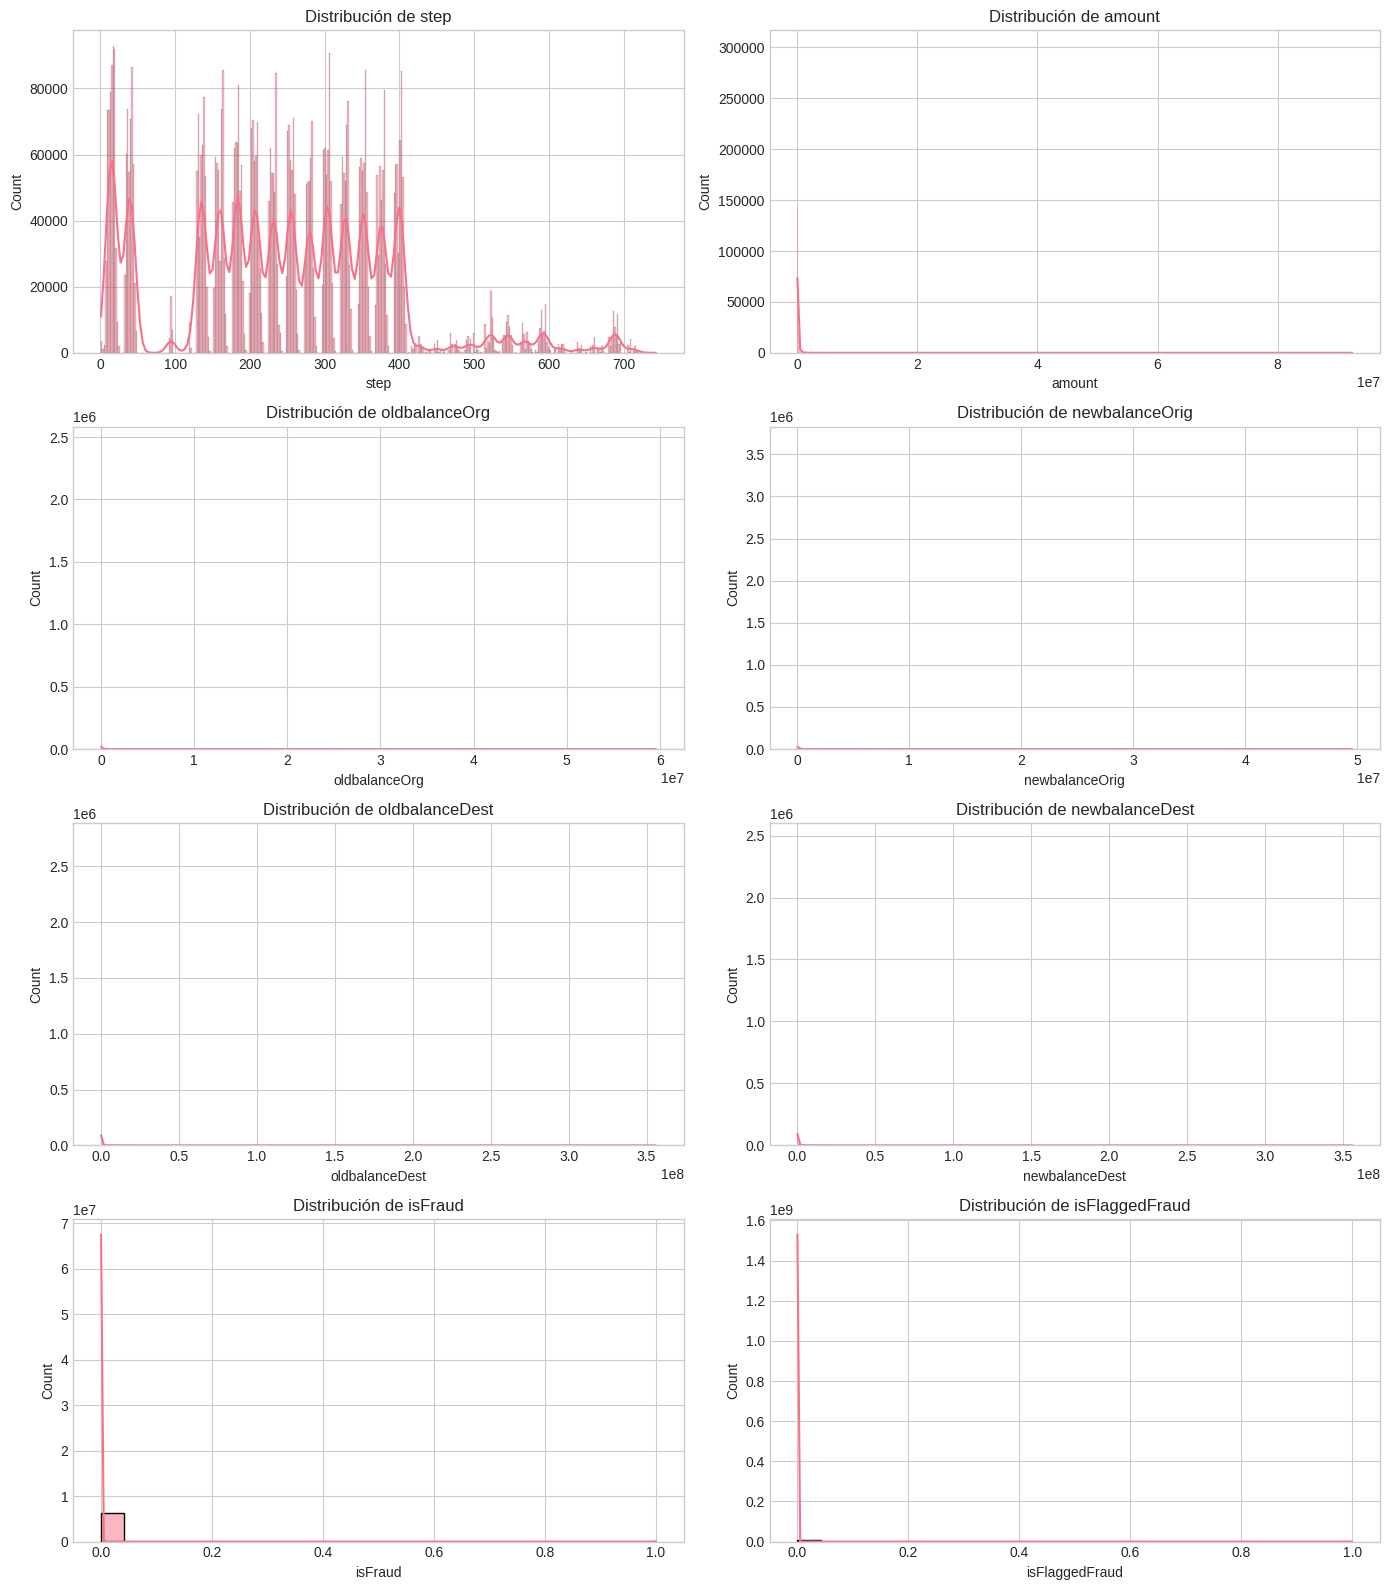

In [ ]:
# =====================================================
# VISUALIZACIONES ADICIONALES
# =====================================================

print("=" * 60)
print("VISUALIZACIONES ADICIONALES")
print("=" * 60)

# Distribución de variables numéricas
numeric_cols_plot = df.select_dtypes(include=[np.number]).columns[:8]  # Primeras 8 columnas

if len(numeric_cols_plot) > 0:
    n_cols = 2
    n_rows = (len(numeric_cols_plot) + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]

    for i, col in enumerate(numeric_cols_plot):
        if i < len(axes):
            sns.histplot(df[col], kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')

    # Ocultar ejes vacíos
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. *El dataset contiene 6,362,620 transacciones y 11 variables, incluyendo información sobre el tipo y monto de la operación, saldos de origen y destino y las variables relacionadas con la identificación de fraude.*
2. *La variable objetivo isFraud presenta un fuerte desbalance de clases: se identificaron 6,354,407 transacciones no fraudulentas y solo 8,213 fraudulentas, lo que representa aproximadamente el 0.13 % del total y un ratio de desbalance de 773.70:1.*
3. *Las correlaciones de las variables numéricas con isFraud son bajas, siendo amount la mayor con aproximadamente 0.08. Asimismo, se observaron correlaciones muy altas entre algunas variables de saldo, como oldbalanceOrg y newbalanceOrig (1.00) y oldbalanceDest y newbalanceDest (0.98).*

**Problemas Identificados:**
1. *Existe un desbalance severo de la variable objetivo, por lo que un modelo podría favorecer excesivamente la clase mayoritaria y presentar dificultades para identificar las transacciones fraudulentas.*
2. *Las variables monetarias presentan distribuciones altamente asimétricas y valores extremos, mientras que algunas variables de saldo presentan una elevada correlación entre sí, aspectos que deben considerarse durante el preprocesamiento y modelado.*

**Acciones a Tomar:**
1. *Aplicar estrategias para manejar el desbalance de clases, considerando alternativas como SMOTE, undersampling o class weights, y utilizar métricas adecuadas para evaluar el desempeño sobre la clase fraudulenta.*
2. *Realizar el preprocesamiento de las variables, considerando la escala y distribución de los valores monetarios y evaluando la posible redundancia entre variables altamente correlacionadas antes del entrenamiento del modelo.*

---

---
## 5. Preprocesamiento de Datos

### 5.1 División de Datos (Train / Validation / Test)

In [13]:
# =====================================================
# DIVISIÓN DE DATOS (ANTES DE CUALQUIER TRANSFORMACIÓN)
# =====================================================

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

df_clean = df.copy()

# Eliminar duplicados exactos (limpieza básica, no genera leakage)
n_dup = df_clean.duplicated().sum()
if n_dup > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"\n🧹 Se eliminaron {n_dup:,} filas duplicadas")

# Tipo de problema: clasificación binaria (isFraud), ya justificado en 3.4.
# Se define UNA sola vez y se reutiliza en el resto del notebook.
task_type = 'classification' if (df_clean[TARGET_COLUMN].dtype == 'object'
                                  or df_clean[TARGET_COLUMN].nunique() < 20) else 'regression'
num_classes = df_clean[TARGET_COLUMN].nunique() if task_type == 'classification' else None
print(f"\n🎯 Tipo de problema: {task_type} | Clases: {num_classes}")

X_raw = df_clean.drop(columns=[TARGET_COLUMN])
y_raw = df_clean[TARGET_COLUMN]

# Dado el desbalance severo (0.13% de fraude, ratio 773.70:1 según EDA 4.4),
# la estratificación NO es opcional aquí: un split aleatorio simple puede dejar
# muy pocos casos de fraude en validación o test.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=RANDOM_SEED, stratify=y_raw
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_SEED, stratify=y_temp  # 0.176 ≈ 15% del total
)

print(f"\n📊 División de datos:")
print(f"   Training set:   {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_raw)*100:.1f}%)")
print(f"   Validation set: {X_val.shape[0]:,} muestras ({X_val.shape[0]/len(X_raw)*100:.1f}%)")
print(f"   Test set:       {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_raw)*100:.1f}%)")

print(f"\n📊 Proporción de fraude por conjunto (debe mantenerse ≈ igual gracias a stratify):")
print(f"   Train: {y_train.mean()*100:.3f}%  |  Val: {y_val.mean()*100:.3f}%  |  Test: {y_test.mean()*100:.3f}%")

DIVISIÓN DE DATOS

🎯 Tipo de problema: classification | Clases: 2

📊 División de datos:
   Training set:   4,456,379 muestras (70.0%)
   Validation set: 951,848 muestras (15.0%)
   Test set:       954,393 muestras (15.0%)

📊 Proporción de fraude por conjunto (debe mantenerse ≈ igual gracias a stratify):
   Train: 0.129%  |  Val: 0.129%  |  Test: 0.129%


### 5.2 Eliminación de Identificadores de Alta Cardinalidad

In [14]:
# =====================================================
# ELIMINACIÓN DE IDENTIFICADORES DE ALTA CARDINALIDAD
# =====================================================

print("=" * 60)
print("IDENTIFICADORES DE ALTA CARDINALIDAD")
print("=" * 60)

# Umbral: una columna categórica con más de CARDINALITY_THRESHOLD valores únicos
# (calculado SOLO sobre train) se trata como identificador, no como categoría.
CARDINALITY_THRESHOLD = 50

candidate_categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
id_like_cols = [c for c in candidate_categorical if X_train[c].nunique() > CARDINALITY_THRESHOLD]

print(f"\nColumnas categóricas encontradas: {candidate_categorical}")
if id_like_cols:
    for c in id_like_cols:
        print(f"   ⚠️ '{c}': {X_train[c].nunique():,} valores únicos en train → se elimina (identificador)")
    X_train = X_train.drop(columns=id_like_cols)
    X_val   = X_val.drop(columns=id_like_cols)
    X_test  = X_test.drop(columns=id_like_cols)
else:
    print("\n✅ No se detectaron identificadores de alta cardinalidad")

print(f"\n✅ Dimensiones tras eliminar identificadores: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")

IDENTIFICADORES DE ALTA CARDINALIDAD

Columnas categóricas encontradas: ['type', 'nameOrig', 'nameDest']
   ⚠️ 'nameOrig': 4,451,806 valores únicos en train → se elimina (identificador)
   ⚠️ 'nameDest': 2,035,657 valores únicos en train → se elimina (identificador)

✅ Dimensiones tras eliminar identificadores: train (4456379, 8), val (951848, 8), test (954393, 8)


### 5.3 Tratamiento de Valores Faltantes

In [15]:
# =====================================================
# TRATAMIENTO DE VALORES FALTANTES (fit en TRAIN, aplicar a TRAIN/VAL/TEST)
# =====================================================

print("=" * 60)
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)

# El EDA (4.4) no reportó valores faltantes en este dataset (PaySim es un simulador
# sin NA por diseño), pero se deja el tratamiento como salvaguarda defensiva y
# reproducible por si cambia la fuente de datos.
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

na_train = X_train.isnull().sum().sum()
print(f"\nNA detectados en train: {na_train}")

from sklearn.impute import SimpleImputer

if na_train > 0:
    if numeric_cols:
        num_imputer = SimpleImputer(strategy='median')
        num_imputer.fit(X_train[numeric_cols])            # fit SOLO con train
        X_train[numeric_cols] = num_imputer.transform(X_train[numeric_cols])
        X_val[numeric_cols]   = num_imputer.transform(X_val[numeric_cols])
        X_test[numeric_cols]  = num_imputer.transform(X_test[numeric_cols])
    if categorical_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        cat_imputer.fit(X_train[categorical_cols])
        X_train[categorical_cols] = cat_imputer.transform(X_train[categorical_cols])
        X_val[categorical_cols]   = cat_imputer.transform(X_val[categorical_cols])
        X_test[categorical_cols]  = cat_imputer.transform(X_test[categorical_cols])
    print(f"\n✅ Valores faltantes imputados (mediana/moda, ajustado solo con train)")
else:
    print(f"\n✅ Sin valores faltantes — no se requiere imputación")

print(f"   NA restantes → train: {X_train.isnull().sum().sum()} | val: {X_val.isnull().sum().sum()} | test: {X_test.isnull().sum().sum()}")


TRATAMIENTO DE VALORES FALTANTES

NA detectados en train: 0

✅ Sin valores faltantes — no se requiere imputación
   NA restantes → train: 0 | val: 0 | test: 0


### 5.4 Variables Monetarias: Detección de Outliers y Transformación Logarítmica

In [16]:
# =====================================================
# DETECCIÓN DE OUTLIERS (diagnóstico, límites SOLO con train)
# =====================================================

print("=" * 60)
print("DETECCIÓN DE OUTLIERS (DIAGNÓSTICO)")
print("=" * 60)

def iqr_bounds(train_series):
    Q1 = train_series.quantile(0.25)
    Q3 = train_series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_summary = []
for col in numeric_cols:
    if X_train[col].nunique() <= 2:
        continue  # columnas binarias (p. ej. isFlaggedFraud) no son candidatas a outliers
    lower, upper = iqr_bounds(X_train[col])
    n_outliers_train = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    if n_outliers_train > 0:
        outlier_summary.append({
            'Variable': col,
            'N_Outliers_Train': n_outliers_train,
            'Porcentaje (%)': round(n_outliers_train / len(X_train) * 100, 2),
        })

if outlier_summary:
    print("\n⚠️ Variables con outliers detectados (según límites de train, solo diagnóstico):")
    display(pd.DataFrame(outlier_summary))

# =====================================================
# TRATAMIENTO: TRANSFORMACIÓN LOGARÍTMICA (no requiere fit, sin riesgo de leakage)
# =====================================================
# Se aplica log1p a las variables numéricas continuas con asimetría relevante
# (skew calculado solo en train) y valores no negativos, típicamente las variables
# monetarias (amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest).
SKEW_THRESHOLD = 1.0
skewed_cols = [
    col for col in numeric_cols
    if X_train[col].nunique() > 2                 # excluir binarias/flags
    and (X_train[col] >= 0).all()                  # log1p requiere valores >= -1
    and abs(X_train[col].skew()) > SKEW_THRESHOLD
]

print(f"\n📐 Variables con asimetría > {SKEW_THRESHOLD} (según train), transformadas con log1p:")
print(f"   {skewed_cols}")

for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_val[col]   = np.log1p(X_val[col])
    X_test[col]  = np.log1p(X_test[col])

print(f"\n✅ Transformación logarítmica aplicada (reduce asimetría, preserva outliers como señal)")

DETECCIÓN DE OUTLIERS (DIAGNÓSTICO)

⚠️ Variables con outliers detectados (según límites de train, solo diagnóstico):


,Variable,N_Outliers_Train,Porcentaje (%)
0,step,71890,1.61
1,amount,236848,5.31
2,oldbalanceOrg,778647,17.47
3,newbalanceOrig,738000,16.56
4,oldbalanceDest,550121,12.34
5,newbalanceDest,516843,11.60



📐 Variables con asimetría > 1.0 (según train), transformadas con log1p:
   ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

✅ Transformación logarítmica aplicada (reduce asimetría, preserva outliers como señal)


### 5.5 Ingeniería de Variables: Discrepancias de Saldo

In [17]:
# =====================================================
# INGENIERÍA DE VARIABLES: DISCREPANCIAS DE SALDO
# =====================================================
# Cálculo determinístico (no requiere fit), aplicable de forma idéntica e
# independiente a train/val/test sin riesgo de leakage.

print("=" * 60)
print("INGENIERÍA DE VARIABLES: DISCREPANCIAS DE SALDO")
print("=" * 60)

required_cols = {'oldbalanceOrg', 'newbalanceOrig', 'amount', 'oldbalanceDest', 'newbalanceDest'}

if required_cols.issubset(X_train.columns):
    for X in (X_train, X_val, X_test):
        X['errorBalanceOrig'] = X['newbalanceOrig'] + X['amount'] - X['oldbalanceOrg']
        X['errorBalanceDest'] = X['oldbalanceDest'] + X['amount'] - X['newbalanceDest']
    print("\n✅ Variables 'errorBalanceOrig' y 'errorBalanceDest' creadas")
    print("   (0 ≈ transacción contablemente consistente; distinto de 0 = posible anomalía)")
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
else:
    faltantes = required_cols - set(X_train.columns)
    print(f"\n⚠️ No se crearon las variables de discrepancia: faltan columnas {faltantes}")
    print("   (verifique los nombres exactos de las columnas de saldo en su dataset)")


INGENIERÍA DE VARIABLES: DISCREPANCIAS DE SALDO

✅ Variables 'errorBalanceOrig' y 'errorBalanceDest' creadas
   (0 ≈ transacción contablemente consistente; distinto de 0 = posible anomalía)


### 5.6 Codificación de la Variable Categórica `type`

In [18]:
# =====================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS (fit en TRAIN)
# =====================================================

print("=" * 60)
print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("=" * 60)

remaining_categorical = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables categóricas a codificar: {remaining_categorical}")

if remaining_categorical:
    # One-Hot Encoding, ajustado SOLO con las categorías vistas en train.
    # handle_unknown='ignore' evita errores si val/test presentan una categoría
    # de 'type' no vista en entrenamiento, y garantiza columnas idénticas en los
    # tres conjuntos (a diferencia de pd.get_dummies aplicado por separado).
    from sklearn.preprocessing import OneHotEncoder

    ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    ohe.fit(X_train[remaining_categorical])

    def apply_ohe(X):
        encoded = ohe.transform(X[remaining_categorical])
        encoded_df = pd.DataFrame(
            encoded, columns=ohe.get_feature_names_out(remaining_categorical), index=X.index
        )
        return pd.concat([X.drop(columns=remaining_categorical), encoded_df], axis=1)

    X_train = apply_ohe(X_train)
    X_val   = apply_ohe(X_val)
    X_test  = apply_ohe(X_test)

print(f"\n✅ Codificación completada")
print(f"   Dimensiones train: {X_train.shape} | val: {X_val.shape} | test: {X_test.shape}")

CODIFICACIÓN DE VARIABLES CATEGÓRICAS

Variables categóricas a codificar: ['type']

✅ Codificación completada
   Dimensiones train: (4456379, 13) | val: (951848, 13) | test: (954393, 13)


### 5.7 Escalado de Features

In [19]:
# =====================================================
# ESCALADO DE FEATURES (fit en TRAIN)
# =====================================================

print("=" * 60)
print("ESCALADO DE FEATURES")
print("=" * 60)

# StandardScaler (media=0, std=1) — recomendado para redes neuronales.
scaler = StandardScaler()
scaler.fit(X_train)   # fit SOLO con train

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),   columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

print(f"\n✅ Escalado completado usando {type(scaler).__name__} (ajustado solo con train)")
print(f"   Media train: {X_train_scaled.mean().mean():.6f} | Std train: {X_train_scaled.std().mean():.6f}")


ESCALADO DE FEATURES

✅ Escalado completado usando StandardScaler (ajustado solo con train)
   Media train: 0.000000 | Std train: 1.000000


### 5.8 Manejo del Desbalance de Clases

In [20]:
# =====================================================
# CÁLCULO DE PESOS DE CLASE (fit conceptual: SOLO con train)
# =====================================================

print("=" * 60)
print("MANEJO DEL DESBALANCE DE CLASES")
print("=" * 60)

from sklearn.utils.class_weight import compute_class_weight

if task_type == 'classification':
    classes = np.sort(y_train.unique())
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights_dict = dict(zip(classes, class_weights))
    class_weights_tensor = torch.FloatTensor(class_weights)

    print(f"\n📊 Pesos de clase (calculados solo con train):")
    print(f"   {class_weights_dict}")
    print("\n   Uso previsto en la sección 7:")
    print("   criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))")
else:
    class_weights_tensor = None

# --- Alternativas (documente en el informe cuál usó y por qué) ---
# Undersampling de la clase mayoritaria (más viable en train que SMOTE, dado el volumen):
# from imblearn.under_sampling import RandomUnderSampler
# rus = RandomUnderSampler(random_state=RANDOM_SEED)
# X_train_scaled, y_train = rus.fit_resample(X_train_scaled, y_train)  # SOLO en train
#
# SMOTE (oversampling, aplicar SOLO en train, nunca en val/test):
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=RANDOM_SEED, sampling_strategy=0.1)  # ratio moderado, no 1:1
# X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print(f"\n✅ Estrategia de desbalance definida (class weights). val/test permanecen SIN alterar,")
print(f"   para que las métricas de la sección 8 reflejen la distribución real de producción.")


MANEJO DEL DESBALANCE DE CLASES

📊 Pesos de clase (calculados solo con train):
   {np.int64(0): np.float64(0.5006462010858246), np.int64(1): np.float64(387.37647774687065)}

   Uso previsto en la sección 7:
   criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

✅ Estrategia de desbalance definida (class weights). val/test permanecen SIN alterar,
   para que las métricas de la sección 8 reflejen la distribución real de producción.


### 5.9 Preparación de Datos para Deep Learning

In [21]:
# =====================================================
# PREPARACIÓN PARA PYTORCH
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA PYTORCH")
print("=" * 60)

X_train_tensor = torch.FloatTensor(X_train_scaled.values)
X_val_tensor   = torch.FloatTensor(X_val_scaled.values)
X_test_tensor  = torch.FloatTensor(X_test_scaled.values)

if task_type == 'classification':
    if y_train.dtype == 'object':
        label_encoder = LabelEncoder()
        label_encoder.fit(y_train)            # fit SOLO con train
        y_train_encoded = label_encoder.transform(y_train)
        y_val_encoded   = label_encoder.transform(y_val)
        y_test_encoded  = label_encoder.transform(y_test)
    else:
        y_train_encoded = y_train.values
        y_val_encoded   = y_val.values
        y_test_encoded  = y_test.values

    y_train_tensor = torch.LongTensor(y_train_encoded)
    y_val_tensor   = torch.LongTensor(y_val_encoded)
    y_test_tensor  = torch.LongTensor(y_test_encoded)
else:
    y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)
    y_val_tensor   = torch.FloatTensor(y_val.values).unsqueeze(1)
    y_test_tensor  = torch.FloatTensor(y_test.values).unsqueeze(1)

BATCH_SIZE = 32  # Ajuste según su dataset; con ~4.4M filas en train, considere valores mayores (128-512)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches de entrenamiento: {len(train_loader)}")
print(f"   Batches de validación: {len(val_loader)}")
print(f"   Batches de test: {len(test_loader)}")

PREPARACIÓN DE DATOS PARA PYTORCH

✅ DataLoaders creados
   Batch size: 32
   Batches de entrenamiento: 139262
   Batches de validación: 29746
   Batches de test: 29825


In [22]:
# =====================================================
# PREPARACIÓN PARA TENSORFLOW/KERAS (ALTERNATIVA)
# =====================================================

print("=" * 60)
print("PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS")
print("=" * 60)

X_train_np = X_train_scaled.values.astype('float32')
X_val_np   = X_val_scaled.values.astype('float32')
X_test_np  = X_test_scaled.values.astype('float32')

if task_type == 'classification':
    y_train_np = keras.utils.to_categorical(y_train_encoded, num_classes)
    y_val_np   = keras.utils.to_categorical(y_val_encoded, num_classes)
    y_test_np  = keras.utils.to_categorical(y_test_encoded, num_classes)
else:
    y_train_np = y_train.values.astype('float32')
    y_val_np   = y_val.values.astype('float32')
    y_test_np  = y_test.values.astype('float32')

print(f"\n✅ Datos preparados para TensorFlow/Keras")
print(f"   Shape X_train: {X_train_np.shape}")
print(f"   Shape y_train: {y_train_np.shape}")

PREPARACIÓN DE DATOS PARA TENSORFLOW/KERAS

✅ Datos preparados para TensorFlow/Keras
   Shape X_train: (4456379, 13)
   Shape y_train: (4456379, 2)


---
## 6. Diseño y Arquitectura del Modelo

### 6.1 Justificación de la Arquitectura

**Instrucciones:** Justifique la elección de su arquitectura de red neuronal:
- ¿Por qué eligió este tipo de arquitectura?
- ¿Qué alternativas consideró?
- ¿Cómo determinó el número de capas y neuronas?

---

Se seleccionó una red neuronal totalmente conectada (MLP) de tres capas ocultas (128 → 64 → 32 neuronas) para la tarea de clasificación binaria de fraude. Esta arquitectura se justifica por las características del problema: los datos son puramente tabulares (montos, saldos y tipo de transacción), sin estructura espacial ni secuencial, por lo que arquitecturas como CNN o RNN no aportan ventaja frente a un MLP y añadirían complejidad innecesaria.

Se evaluaron como alternativas modelos de árboles (Random Forest, XGBoost/LightGBM), que suelen ser muy competitivos en datos tabulares desbalanceados; de hecho, uno de ellos se usa como baseline en la sección 8.2 para contrastar el desempeño de la red neuronal. Se optó por complementar con deep learning para explorar la capacidad de una red de aprender interacciones no lineales entre variables de saldo (errorBalanceOrig, errorBalanceDest) y monto, y para cumplir con el objetivo del curso de aplicar deep learning al caso de negocio.

El número de capas y neuronas se determinó de forma empírica-heurística: se partió de una capa de entrada acorde al número de features (~13, tras eliminar identificadores de alta cardinalidad y codificar type), y se aplicó una reducción progresiva de neuronas (128-64-32) siguiendo la práctica común de "embudo", que permite a las primeras capas capturar combinaciones más generales de las variables y a las capas más profundas refinar representaciones más abstractas y específicas del patrón de fraude. Dado el fuerte desbalance de clases (773.70:1), cada capa oculta incluye BatchNorm (estabiliza el entrenamiento), ReLU (no linealidad estándar) y Dropout (0.3) para mitigar el sobreajuste, dado que las transacciones fraudulentas son escasas y el riesgo de memorización es alto. La capa de salida tiene 2 neuronas con activación softmax (equivalente a 1 neurona con sigmoide para este caso binario), y el desbalance se compensa en el entrenamiento con pesos de clase (class_weights_tensor, calculados en 5.8), no con más capacidad de red.


---

### 6.2 Definición del Modelo

In [23]:
# =====================================================
# DEFINICIÓN DEL MODELO CON PYTORCH
# =====================================================

class NeuralNetwork(nn.Module):
    """
    Red Neuronal para [Clasificación/Regresión]

    Arquitectura:
    - Capa de entrada: [n_features] neuronas
    - Capas ocultas: [Describir]
    - Capa de salida: [n_outputs] neuronas
    """

    def __init__(self, input_size, hidden_sizes, output_size, dropout_rate=0.3):
        super(NeuralNetwork, self).__init__()

        layers = []
        prev_size = input_size

        # Capas ocultas
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        # Capa de salida
        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# =====================================================
# CONFIGURACIÓN DEL MODELO
# =====================================================

INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZES = [128, 64, 32]  # Ajuste según su problema
OUTPUT_SIZE = y_raw.nunique() if (y_raw.dtype == 'object' or y_raw.nunique() < 20) else 1
DROPOUT_RATE = 0.3

# Crear modelo
model_pytorch = NeuralNetwork(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE, DROPOUT_RATE)
model_pytorch = model_pytorch.to(device)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (PyTorch)")
print("=" * 60)
print(model_pytorch)

# Contar parámetros
total_params = sum(p.numel() for p in model_pytorch.parameters())
trainable_params = sum(p.numel() for p in model_pytorch.parameters() if p.requires_grad)
print(f"\n📊 Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

ARQUITECTURA DEL MODELO (PyTorch)
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=2, bias=True)
  )
)

📊 Parámetros totales: 12,642
   Parámetros entrenables: 12,642


In [24]:
# =====================================================
# DEFINICIÓN DEL MODELO CON KERAS (ALTERNATIVA)
# =====================================================

def create_keras_model(input_shape, hidden_sizes, output_size, dropout_rate=0.3, task='classification'):
    """
    Crea un modelo de red neuronal con Keras.

    Args:
        input_shape: Dimensión de entrada
        hidden_sizes: Lista con el número de neuronas por capa oculta
        output_size: Número de neuronas de salida
        dropout_rate: Tasa de dropout
        task: 'classification' o 'regression'
    """
    model = keras.Sequential()

    # Capa de entrada
    model.add(layers.Input(shape=(input_shape,)))

    # Capas ocultas
    for hidden_size in hidden_sizes:
        model.add(layers.Dense(hidden_size))
        model.add(layers.BatchNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida
    if task == 'classification':
        if output_size == 2:
            model.add(layers.Dense(1, activation='sigmoid'))
        else:
            model.add(layers.Dense(output_size, activation='softmax'))
    else:
        model.add(layers.Dense(1, activation='linear'))

    return model

# Crear modelo Keras
TASK = 'classification'  # Cambie a 'regression' si es necesario

model_keras = create_keras_model(
    input_shape=INPUT_SIZE,
    hidden_sizes=HIDDEN_SIZES,
    output_size=OUTPUT_SIZE,
    dropout_rate=DROPOUT_RATE,
    task=TASK
)

print("=" * 60)
print("ARQUITECTURA DEL MODELO (Keras)")
print("=" * 60)
model_keras.summary()

ARQUITECTURA DEL MODELO (Keras)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 448 (1.75 KB)

### 6.3 Diagrama de la Arquitectura

**Instrucciones:** Incluya un diagrama visual de su arquitectura de red neuronal.

---

```
Capa de entrada        Capa oculta 1          Capa oculta 2          Capa oculta 3          Capa de salida
[13 features]   -->   [128 neuronas]   -->   [64 neuronas]    -->   [32 neuronas]   -->    [2 neuronas]
                       + BatchNorm            + BatchNorm            + BatchNorm            (softmax)
                       + ReLU                 + ReLU                 + ReLU
                       + Dropout(0.3)         + Dropout(0.3)         + Dropout(0.3)

Total de parámetros entrenables: 12,642
```

---

---
## 7. Entrenamiento del Modelo

### 7.1 Configuración del Entrenamiento

In [29]:
# =====================================================
# HIPERPARÁMETROS DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CONFIGURACIÓN DEL ENTRENAMIENTO")
print("=" * 60)

# Hiperparámetros
LEARNING_RATE = 0.001
EPOCHS = 20
BATCH_SIZE = 512
EARLY_STOPPING_PATIENCE = 8

# Métricas objetivo del proyecto
TARGET_RECALL = 0.90
TARGET_AUPRC = 0.85

# Recrear DataLoaders con un batch mayor para aprovechar la GPU
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

print(f"\n📋 Hiperparámetros:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"   Recall objetivo: ≥ {TARGET_RECALL:.0%}")
print(f"   AUPRC objetivo: > {TARGET_AUPRC:.2f}")

print(f"\n🚀 DataLoaders actualizados:")
print(f"   Batches de entrenamiento: {len(train_loader):,}")
print(f"   Batches de validación: {len(val_loader):,}")

CONFIGURACIÓN DEL ENTRENAMIENTO

📋 Hiperparámetros:
   Learning Rate: 0.001
   Epochs: 20
   Batch Size: 512
   Early Stopping Patience: 8
   Recall objetivo: ≥ 90%
   AUPRC objetivo: > 0.85

🚀 DataLoaders actualizados:
   Batches de entrenamiento: 8,704
   Batches de validación: 1,860


In [30]:
# =====================================================
# CONFIGURACIÓN DE LOSS Y OPTIMIZADOR (PyTorch)
# =====================================================

# El problema ya fue definido como clasificación binaria en la sección 5.1
task_type = 'classification'

# Función de pérdida ponderada para manejar el fuerte desbalance de clases
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)

# Optimizador
optimizer = optim.Adam(
    model_pytorch.parameters(),
    lr=LEARNING_RATE
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(f"\n📋 Configuración:")
print(f"   Tipo de problema: {task_type}")
print(f"   Función de pérdida: CrossEntropyLoss ponderada")
print(f"   Pesos de clase: {class_weights_dict}")
print(f"   Optimizador: Adam")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Dispositivo: {device}")


📋 Configuración:
   Tipo de problema: classification
   Función de pérdida: CrossEntropyLoss ponderada
   Pesos de clase: {np.int64(0): np.float64(0.5006462010858246), np.int64(1): np.float64(387.37647774687065)}
   Optimizador: Adam
   Scheduler: ReduceLROnPlateau
   Dispositivo: cuda


### 7.2 Entrenamiento del Modelo (PyTorch)

In [31]:
# =====================================================
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN
# =====================================================

from sklearn.metrics import recall_score, average_precision_score


def train_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época."""

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )

        # Reiniciar gradientes
        optimizer.zero_grad()

        # Forward
        outputs = model(X_batch)

        # Calcular pérdida
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Actualizar parámetros
        optimizer.step()

        total_loss += loss.item()

        # Accuracy
        predicted = torch.argmax(
            outputs,
            dim=1
        )

        total += y_batch.size(0)

        correct += (
            predicted == y_batch
        ).sum().item()

    avg_loss = total_loss / len(train_loader)

    accuracy = correct / total

    return avg_loss, accuracy



def evaluate(model, val_loader, criterion, device):
    """
    Evalúa el modelo y calcula métricas enfocadas
    en la detección de fraude.
    """

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(
                device,
                non_blocking=True
            )

            y_batch = y_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += loss.item()

            # Probabilidad de fraude (clase 1)
            probabilities = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            predicted = torch.argmax(
                outputs,
                dim=1
            )

            total += y_batch.size(0)

            correct += (
                predicted == y_batch
            ).sum().item()

            # Guardar resultados por batch
            all_targets.append(
                y_batch.cpu().numpy()
            )

            all_predictions.append(
                predicted.cpu().numpy()
            )

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    # Unir resultados
    y_true = np.concatenate(all_targets)

    y_pred = np.concatenate(
        all_predictions
    )

    y_prob = np.concatenate(
        all_probabilities
    )

    avg_loss = (
        total_loss / len(val_loader)
    )

    accuracy = correct / total

    # Recall específico de fraude
    recall_fraud = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    # Área bajo la curva Precision-Recall
    auprc = average_precision_score(
        y_true,
        y_prob
    )

    return (
        avg_loss,
        accuracy,
        recall_fraud,
        auprc
    )

In [32]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (PyTorch)
# =====================================================

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO")
print("=" * 60)

# Historial de entrenamiento
history = {

    'train_loss': [],
    'val_loss': [],

    'train_acc': [],
    'val_acc': [],

    'val_recall': [],
    'val_auprc': []
}

# Early stopping
best_val_auprc = 0

patience_counter = 0

best_model_state = None


print(f"\n🚀 Iniciando entrenamiento...\n")


for epoch in range(EPOCHS):

    # =================================================
    # ENTRENAMIENTO
    # =================================================

    train_loss, train_acc = train_epoch(

        model_pytorch,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # =================================================
    # VALIDACIÓN
    # =================================================

    (
        val_loss,
        val_acc,
        val_recall,
        val_auprc

    ) = evaluate(

        model_pytorch,
        val_loader,
        criterion,
        device
    )


    # =================================================
    # GUARDAR HISTORIAL
    # =================================================

    history['train_loss'].append(
        train_loss
    )

    history['val_loss'].append(
        val_loss
    )

    history['train_acc'].append(
        train_acc
    )

    history['val_acc'].append(
        val_acc
    )

    history['val_recall'].append(
        val_recall
    )

    history['val_auprc'].append(
        val_auprc
    )


    # =================================================
    # SCHEDULER
    # =================================================

    scheduler.step(val_loss)


    # =================================================
    # MOSTRAR PROGRESO
    # =================================================

    if (
        (epoch + 1) % 10 == 0
        or epoch == 0
    ):

        print(

            f"Época {epoch+1:3d}/{EPOCHS} | "

            f"Train Loss: {train_loss:.4f} | "

            f"Val Loss: {val_loss:.4f} | "

            f"Val Acc: {val_acc:.4f} | "

            f"Recall Fraude: {val_recall:.4f} | "

            f"AUPRC: {val_auprc:.4f}"
        )


    # =================================================
    # EARLY STOPPING SEGÚN AUPRC
    # =================================================

    if val_auprc > best_val_auprc:

        best_val_auprc = val_auprc

        patience_counter = 0

        # Guardar mejor modelo en CPU
        best_model_state = {

            k: v.detach().cpu().clone()

            for k, v
            in model_pytorch.state_dict().items()
        }

    else:

        patience_counter += 1


        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                f"\n⚠️ Early stopping "
                f"en época {epoch+1}"
            )

            break


# =====================================================
# CARGAR MEJOR MODELO
# =====================================================

if best_model_state is not None:

    model_pytorch.load_state_dict(
        best_model_state
    )

    model_pytorch.to(device)

    print(
        f"\n✅ Mejor modelo cargado "
        f"(Val AUPRC: "
        f"{best_val_auprc:.4f})"
    )


print("\n🎉 Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO

🚀 Iniciando entrenamiento...

Época   1/20 | Train Loss: 0.0381 | Val Loss: 0.0259 | Val Acc: 0.9850 | Recall Fraude: 0.9992 | AUPRC: 0.8950
Época  10/20 | Train Loss: 0.0360 | Val Loss: 0.0211 | Val Acc: 0.9910 | Recall Fraude: 0.9992 | AUPRC: 0.9033
Época  20/20 | Train Loss: 0.0333 | Val Loss: 0.0213 | Val Acc: 0.9875 | Recall Fraude: 0.9992 | AUPRC: 0.9059

✅ Mejor modelo cargado (Val AUPRC: 0.9151)

🎉 Entrenamiento completado!


### 7.3 Entrenamiento del Modelo (Keras - Alternativa)

In [33]:
# =====================================================
# ENTRENAMIENTO DEL MODELO (KERAS)
# =====================================================

# =====================================================
# PREPARAR ETIQUETAS PARA SALIDA SIGMOID
# =====================================================

if y_train_np.ndim > 1:

    y_train_keras = np.argmax(
        y_train_np,
        axis=1
    )

    y_val_keras = np.argmax(
        y_val_np,
        axis=1
    )

else:

    y_train_keras = y_train_np

    y_val_keras = y_val_np


# =====================================================
# MÉTRICAS
# =====================================================

recall_metric = keras.metrics.Recall(
    name='recall'
)

auprc_metric = keras.metrics.AUC(
    curve='PR',
    name='auprc'
)


# =====================================================
# COMPILAR MODELO
# =====================================================

model_keras.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy',
        recall_metric,
        auprc_metric
    ]
)


# =====================================================
# PESOS DE CLASE
# =====================================================

class_weight_keras = {

    int(clase): float(peso)

    for clase, peso
    in class_weights_dict.items()
}


# =====================================================
# CALLBACKS
# =====================================================

keras_callbacks = [

    callbacks.EarlyStopping(

        monitor='val_auprc',

        mode='max',

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1
    ),

    callbacks.ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.5,

        patience=5,

        verbose=1
    ),

    callbacks.ModelCheckpoint(

        'best_model.keras',

        monitor='val_auprc',

        mode='max',

        save_best_only=True,

        verbose=0
    )
]


# =====================================================
# ENTRENAR
# =====================================================

print("=" * 60)
print("ENTRENAMIENTO DEL MODELO (KERAS)")
print("=" * 60)


history_keras = model_keras.fit(

    X_train_np,

    y_train_keras,

    validation_data=(

        X_val_np,
        y_val_keras
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    class_weight=class_weight_keras,

    callbacks=keras_callbacks,

    verbose=1
)


print("\n🎉 Entrenamiento completado!")

ENTRENAMIENTO DEL MODELO (KERAS)
Epoch 1/20
8704/8704 ━━━━━━━━━━━━━━━━━━━━ 54s 5ms/step - accuracy: 0.9420 - auprc: 0.3710 - loss: 0.1409 - recall: 0.9684 - val_accuracy: 0.9717 - val_auprc: 0.8431 - val_loss: 0.0613 - val_recall: 0.9992 - learning_rate: 0.0010
Epoch 2/20
8704/8704 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9698 - auprc: 0.4442 - loss: 0.0741 - recall: 0.9838 - val_accuracy: 0.9783 - val_auprc: 0.8248 - val_loss: 0.0483 - val_recall: 0.9992 - learning_rate: 0.0010
Epoch 3/20
8704/8704 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.9737 - auprc: 0.4507 - loss: 0.0781 - recall: 0.9852 - val_accuracy: 0.9775 - val_auprc: 0.8589 - val_loss: 0.0467 - val_recall: 0.9992 - learning_rate: 0.0010
Epoch 4/20
8704/8704 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.9754 - auprc: 0.4542 - loss: 0.0588 - recall: 0.9878 - val_accuracy: 0.9796 - val_auprc: 0.8659 - val_loss: 0.0417 - val_recall: 0.9992 - learning_rate: 0.0010
Epoch 5/20
8704/8704 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/s

### 7.4 Visualización del Entrenamiento

CURVAS DE APRENDIZAJE


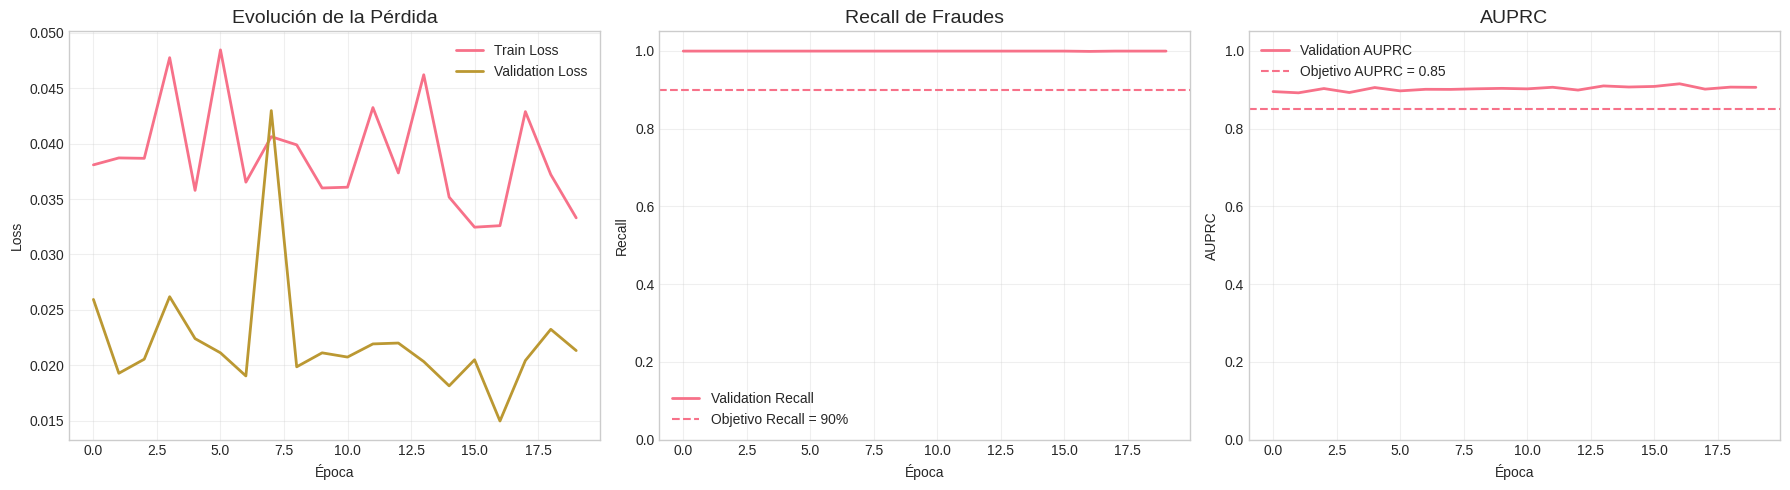


📊 Análisis del Entrenamiento:
   Épocas completadas: 20
   Mejor Recall validación: 0.9992
   Mejor AUPRC validación: 0.9151
   ✅ Objetivo Recall ≥ 90% alcanzado
   ✅ Objetivo AUPRC > 0.85 alcanzado


In [34]:
# =====================================================
# VISUALIZACIÓN DEL PROCESO DE ENTRENAMIENTO
# =====================================================

print("=" * 60)
print("CURVAS DE APRENDIZAJE")
print("=" * 60)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# =====================================================
# GRÁFICO DE PÉRDIDA
# =====================================================

axes[0].plot(

    history['train_loss'],

    label='Train Loss',

    linewidth=2
)

axes[0].plot(

    history['val_loss'],

    label='Validation Loss',

    linewidth=2
)

axes[0].set_title(
    'Evolución de la Pérdida',
    fontsize=14
)

axes[0].set_xlabel('Época')

axes[0].set_ylabel('Loss')

axes[0].legend()

axes[0].grid(
    True,
    alpha=0.3
)


# =====================================================
# RECALL DE FRAUDE
# =====================================================

axes[1].plot(

    history['val_recall'],

    label='Validation Recall',

    linewidth=2
)

axes[1].axhline(

    y=TARGET_RECALL,

    linestyle='--',

    label='Objetivo Recall = 90%'
)

axes[1].set_title(
    'Recall de Fraudes',
    fontsize=14
)

axes[1].set_xlabel('Época')

axes[1].set_ylabel('Recall')

axes[1].set_ylim(0, 1.05)

axes[1].legend()

axes[1].grid(
    True,
    alpha=0.3
)


# =====================================================
# AUPRC
# =====================================================

axes[2].plot(

    history['val_auprc'],

    label='Validation AUPRC',

    linewidth=2
)

axes[2].axhline(

    y=TARGET_AUPRC,

    linestyle='--',

    label='Objetivo AUPRC = 0.85'
)

axes[2].set_title(
    'AUPRC',
    fontsize=14
)

axes[2].set_xlabel('Época')

axes[2].set_ylabel('AUPRC')

axes[2].set_ylim(0, 1.05)

axes[2].legend()

axes[2].grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# =====================================================
# RESUMEN DEL ENTRENAMIENTO
# =====================================================

best_recall = max(
    history['val_recall']
)

best_auprc = max(
    history['val_auprc']
)


print("\n📊 Análisis del Entrenamiento:")

print(
    f"   Épocas completadas: "
    f"{len(history['train_loss'])}"
)

print(
    f"   Mejor Recall validación: "
    f"{best_recall:.4f}"
)

print(
    f"   Mejor AUPRC validación: "
    f"{best_auprc:.4f}"
)


# =====================================================
# VALIDAR OBJETIVOS
# =====================================================

if best_recall >= TARGET_RECALL:

    print(
        "   ✅ Objetivo Recall ≥ 90% alcanzado"
    )

else:

    print(
        "   ⚠️ Objetivo Recall ≥ 90% no alcanzado"
    )


if best_auprc > TARGET_AUPRC:

    print(
        "   ✅ Objetivo AUPRC > 0.85 alcanzado"
    )

else:

    print(
        "   ⚠️ Objetivo AUPRC > 0.85 no alcanzado"
    )

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

In [ ]:
# =====================================================
# EVALUACIÓN EN EL CONJUNTO DE TEST
# =====================================================

print("=" * 60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("=" * 60)

# Hacer predicciones
model_pytorch.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    outputs = model_pytorch(X_test_device)

    if task_type == 'classification':
        _, y_pred = torch.max(outputs, 1)
        y_pred = y_pred.cpu().numpy()
        y_true = y_test_tensor.numpy()
        y_proba = torch.softmax(outputs, dim=1).cpu().numpy()
    else:
        y_pred = outputs.cpu().numpy().flatten()
        y_true = y_test_tensor.numpy().flatten()

print(f"\n✅ Predicciones realizadas: {len(y_pred)} muestras")

In [ ]:
# =====================================================
# MÉTRICAS DE CLASIFICACIÓN
# =====================================================

if task_type == 'classification':
    print("=" * 60)
    print("MÉTRICAS DE CLASIFICACIÓN")
    print("=" * 60)

    # Calcular métricas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n📊 Métricas Principales:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

    # Reporte de clasificación completo
    print(f"\n📋 Reporte de Clasificación Detallado:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(OUTPUT_SIZE),
                yticklabels=range(OUTPUT_SIZE))
    plt.title('Matriz de Confusión', fontsize=14)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# MÉTRICAS DE REGRESIÓN
# =====================================================

if task_type == 'regression':
    print("=" * 60)
    print("MÉTRICAS DE REGRESIÓN")
    print("=" * 60)

    # Calcular métricas
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 Métricas de Regresión:")
    print(f"   MSE:  {mse:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")

    # Gráfico de predicciones vs valores reales
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_xlabel('Valor Real')
    axes[0].set_ylabel('Predicción')
    axes[0].set_title('Predicciones vs Valores Reales')

    # Distribución de residuos
    residuos = y_true - y_pred
    axes[1].hist(residuos, bins=50, edgecolor='black')
    axes[1].axvline(x=0, color='r', linestyle='--')
    axes[1].set_xlabel('Residuo')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')

    plt.tight_layout()
    plt.show()

### 8.2 Comparación con Modelo Baseline

In [ ]:
# =====================================================
# COMPARACIÓN CON MODELO BASELINE
# =====================================================

print("=" * 60)
print("COMPARACIÓN CON MODELO BASELINE")
print("=" * 60)

if task_type == 'classification':
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.linear_model import LogisticRegression

    # Modelos baseline
    baselines = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
    }
else:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression

    baselines = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
    }

# Entrenar y evaluar baselines
results = {'Modelo': [], 'Métrica': []}

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred_baseline = model.predict(X_test)

    if task_type == 'classification':
        metric = accuracy_score(y_test, y_pred_baseline)
        metric_name = 'Accuracy'
    else:
        metric = r2_score(y_test, y_pred_baseline)
        metric_name = 'R²'

    results['Modelo'].append(name)
    results['Métrica'].append(metric)

# Agregar modelo de Deep Learning
results['Modelo'].append('Deep Learning')
if task_type == 'classification':
    results['Métrica'].append(accuracy)
else:
    results['Métrica'].append(r2)

# Mostrar comparación
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Métrica', ascending=False)

print(f"\n📊 Comparación de Modelos ({metric_name}):")
display(comparison_df)

# Visualización
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == 'Deep Learning' else '#3498db' for m in comparison_df['Modelo']]
plt.barh(comparison_df['Modelo'], comparison_df['Métrica'], color=colors)
plt.xlabel(metric_name)
plt.title(f'Comparación de Modelos - {metric_name}')
plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

**Instrucciones:** Analice los resultados obtenidos:

---

**Rendimiento del Modelo:**
*[Analice las métricas obtenidas]*

**Comparación con Baselines:**
*[Compare el rendimiento con los modelos baseline]*

**Fortalezas del Modelo:**
1. *[Completar]*
2. *[Completar]*

**Debilidades del Modelo:**
1. *[Completar]*
2. *[Completar]*

**Posibles Mejoras:**
1. *[Completar]*
2. *[Completar]*

---

---
## 9. Interpretación de Resultados

### 9.1 Importancia de Features (SHAP)

In [ ]:
# =====================================================
# INTERPRETABILIDAD CON SHAP (OPCIONAL)
# =====================================================

# Instalar SHAP si no está disponible
# !pip install shap

try:
    import shap

    print("=" * 60)
    print("ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)")
    print("=" * 60)

    # Crear explainer
    # Usar una muestra del dataset para acelerar el cálculo
    sample_size = min(100, len(X_test))
    X_sample = X_test.iloc[:sample_size]

    # Para modelos de sklearn (baselines)
    explainer = shap.TreeExplainer(baselines['Random Forest'])
    shap_values = explainer.shap_values(X_sample)

    # Visualización
    plt.figure(figsize=(12, 8))
    if task_type == 'classification' and len(shap_values) > 1:
        shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    else:
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Importancia de Features (SHAP)')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ SHAP no está instalado. Ejecute: !pip install shap")
except Exception as e:
    print(f"⚠️ Error en análisis SHAP: {e}")

### 9.2 Interpretación de Negocios

**Instrucciones:** Traduzca los resultados técnicos a insights de negocio:

---

**Insights Principales:**
1. *[Insight 1 - ¿Qué significa el resultado para el negocio?]*
2. *[Insight 2]*
3. *[Insight 3]*

**Factores Más Importantes:**
*[¿Cuáles son los factores más importantes según el modelo y qué significan para el negocio?]*

**Patrones Identificados:**
*[¿Qué patrones ha identificado el modelo que pueden ser relevantes para la toma de decisiones?]*

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

**Instrucciones:** Proporcione un resumen ejecutivo de los resultados:

---

*[Resuma los principales resultados del proyecto en 2-3 párrafos]*

---

### 10.2 Conclusiones

**Instrucciones:** Liste las conclusiones principales:

---

1. *[Conclusión 1]*
2. *[Conclusión 2]*
3. *[Conclusión 3]*
4. *[Conclusión 4]*

---

### 10.3 Recomendaciones de Negocio

**Instrucciones:** Proporcione recomendaciones accionables basadas en los resultados:

---

**Recomendaciones a Corto Plazo:**
1. *[Recomendación 1]*
2. *[Recomendación 2]*

**Recomendaciones a Mediano Plazo:**
1. *[Recomendación 1]*
2. *[Recomendación 2]*

**Recomendaciones a Largo Plazo:**
1. *[Recomendación 1]*
2. *[Recomendación 2]*

---

### 10.4 Limitaciones del Estudio

**Instrucciones:** Identifique las limitaciones de su análisis:

---

1. *[Limitación 1]*
2. *[Limitación 2]*
3. *[Limitación 3]*

---

### 10.5 Trabajo Futuro

**Instrucciones:** Proponga líneas de investigación futura:

---

1. *[Propuesta 1]*
2. *[Propuesta 2]*
3. *[Propuesta 3]*

---

---
## 11. Referencias

**Instrucciones:** Liste todas las referencias utilizadas (formato APA):

---

1. *[Referencia 1]*
2. *[Referencia 2]*
3. *[Referencia 3]*

---

---
## Anexos

### A. Guardado del Modelo

In [ ]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

### B. Cargar Modelo Guardado (para Inferencia)

In [ ]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓